# Ноутбук для всяких картинок для отчетов

In [4]:
cd ../src/train_VAE

/home/rfit/Telescope_Array/phd_work/src/train_VAE


In [5]:
!pwd

/home/rfit/Telescope_Array/phd_work/src/train_VAE


In [6]:
import pipline







Using device: cuda


2025-11-22 17:52:48.279814: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763823168.734779   32970 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763823168.849497   32970 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1763823169.964079   32970 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1763823169.964122   32970 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1763823169.964128   32970 computation_placer.cc:177] computation placer alr

In [7]:
pip = pipline.Pipline("config.yaml")

['catboost_info', 'pipline.py', '__pycache__', 'show_loss.py', 'model_old.py', 'metric.py', 'loss_hist.png', 'runs', 'datasets.py', 'runs_tests', 'model.py', 'loss.py', 'tests', 'utils.py', 'init.sh', 'config.yaml', '__init__.py', 'for_temporary_work', '.ipynb_checkpoints']
Encoder has params: 1791304 Decoder has params: 777144
split_num 100000 <class 'int'>
Saving Path: /home/rfit/Telescope_Array/phd_work/Models/AutoEncoder/small_decoder_VAE_V8_TEST


In [9]:
for data,part,params_CR in pip.val_loaders[0]:
    print(data.shape)
    print(part.shape)
    print(params_CR.shape)
    break

torch.Size([100, 32, 6])
torch.Size([100])
torch.Size([100, 3])


/home/rfit/Telescope_Array/phd_work/src/train_VAE/datasets.py:137: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(x), torch.tensor(mc_params[1]), torch.tensor(params_CR)


In [12]:
from typing import Optional, Tuple, Union
import numpy as np
import torch
import matplotlib.pyplot as plt

def clean_mask(data: torch.Tensor, tokens: Optional[Tuple[int, int, int]] =None, lenght: Optional[int]=None) -> torch.Tensor:
    """
    This function cleans a masked tensor by removing start, end, and mask tokens, and adjusting the length accordingly.

    Parameters:
    - data (torch.Tensor): The input tensor to be cleaned. It should be of shape (sequence_length, features).
    - tokens (Optional[Tuple[int, int, int]]): A tuple containing the start token, end token, and mask token. If None, default values will be used.

    Returns:
    torch.Tensor: The cleaned tensor with the start, end, and mask tokens removed, and the length adjusted accordingly.
    """
    if lenght is not None:
        return data[:lenght], lenght
    st, fn, ms = tokens
    mask = torch.where(data != ms, 1, 0)
    lenght = torch.sum(mask[:,0]) # length but used st and fn tokens
    if fn is not None:
        lenght-=1 # fn token is not real data
    if st is not None:
        data = data[1:] # del first data
        lenght-=1
    return data[:lenght], lenght  

def show_data(data, tokens: Optional[Tuple[int, int, int]]=None,
               lenght_predict: Union[np.ndarray, torch.Tensor] = None) -> plt.figure:
    '''
    data - shape (det, featches)

    fake - shape (det, featches)

    return: fig
    '''

    #TODO переписать нормально
    data, real_lenght = clean_mask(data, tokens = tokens)
    names = ['det x', 'det y', 'det z', 'signal', 'flat front', '(real - front)']
    fig, axs = plt.subplots(2,3, figsize = (10,10))
    for i in range(6):
        row = i%2
        col = i//2
        axs[row][col].plot(data.to('cpu').detach().numpy()[:,i], 'b')
        axs[row][col].legend(['true', 'true'])
        axs[row][col].set_title(f'chanal {names[i]}')
    lenght_info = f'real_lenght {real_lenght}'
    plt.suptitle(lenght_info)
    return fig

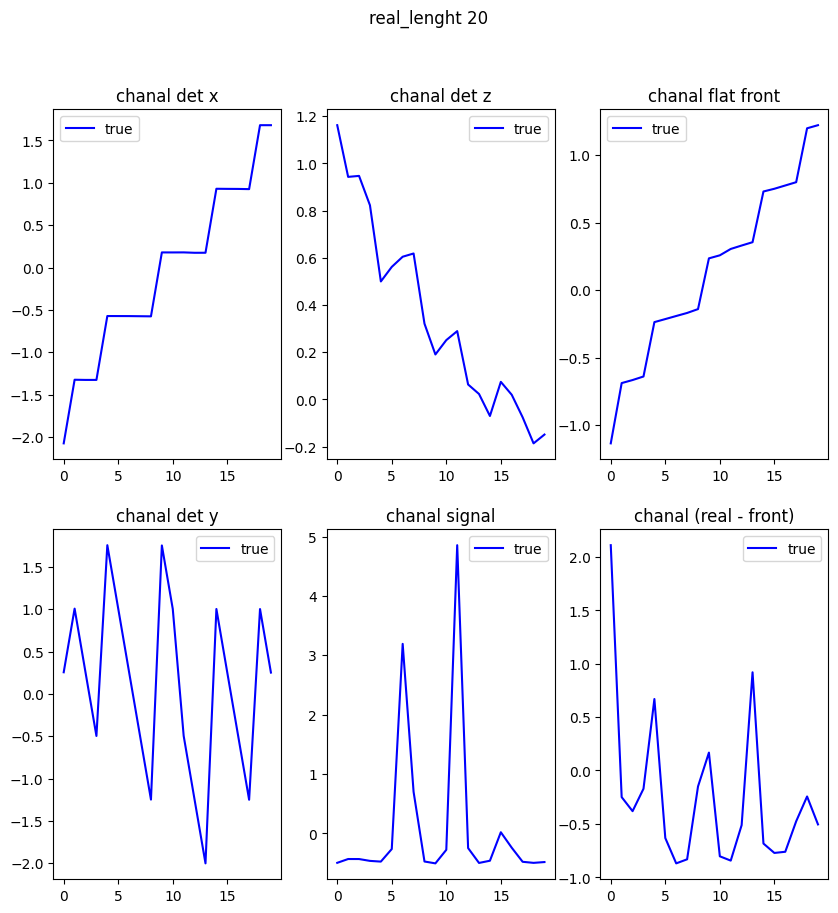

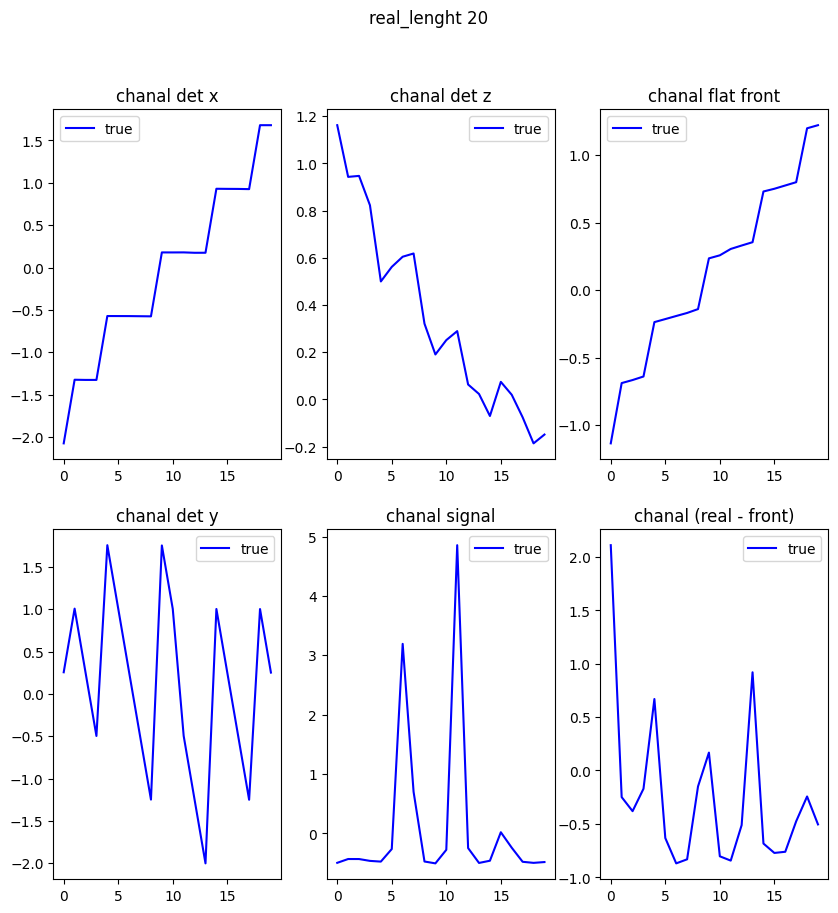

In [13]:
show_data(data[1], tokens = (10, -10, -11))